In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [25]:
data=pd.read_csv('supermercados.csv')
data.head()

,url,nombre,descripcion,precio,imagen,supermercado,categoria,ruta_imagen,descripcion_limpia
0,https://www.plazavea.com.pe/limon-acido-pro/p,Limón Ácido,VERDURAS El consumo adecuado de Frutas y Verd...,3.89,https://plazavea.vteximg.com.br/arquivos/ids/1...,Plaza Vea,frutas y verduras,supermercados\plazavea_imagenes\limon-acido-pr...,verduras consumo adecuado frutas verduras fuen...
1,https://www.plazavea.com.pe/mix-blueberries-ag...,Mix Blueberries Aguaymanto BELL'S Bandeja 300g,FRUTAS El consumo adecuado de Frutas y Verdur...,10.90,https://plazavea.vteximg.com.br/arquivos/ids/6...,Plaza Vea,frutas y verduras,supermercados\plazavea_imagenes\mix-blueberrie...,frutas consumo adecuado frutas verduras fuente...
2,https://www.plazavea.com.pe/naranja-para-jugo-b/p,Naranja para Jugo,FRUTAS El consumo adecuado de Frutas y Verdur...,2.49,https://plazavea.vteximg.com.br/arquivos/ids/1...,Plaza Vea,frutas y verduras,supermercados\plazavea_imagenes\naranja-para-j...,frutas consumo adecuado frutas verduras fuente...
3,https://www.plazavea.com.pe/tomate-italiano-be...,Tomate Italiano BELL'S Bolsa 1Kg,VERDURAS El consumo adecuado de Frutas y Verd...,6.99,https://plazavea.vteximg.com.br/arquivos/ids/5...,Plaza Vea,frutas y verduras,supermercados\plazavea_imagenes\azucar-blanca-...,verduras consumo adecuado frutas verduras fuen...
4,https://www.plazavea.com.pe/beterraga-x-unidad/p,Beterraga x Atado,VERDURAS El consumo adecuado de Frutas y Verd...,2.99,https://plazavea.vteximg.com.br/arquivos/ids/1...,Plaza Vea,frutas y verduras,supermercados\plazavea_imagenes\beterraga-x-un...,verduras consumo adecuado frutas verduras fuen...


# Análisis Exploratorio de Datos - Supermercados

## 1. Información General del Dataset

In [26]:
# 1. Información básica del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(f"Forma del dataset: {data.shape}")
print(f"Número de filas: {data.shape[0]:,}")
print(f"Número de columnas: {data.shape[1]}")
print("\nNombres de las columnas:")
print(data.columns.tolist())
print("\nTipos de datos:")
print(data.dtypes)
print("\nInformación detallada:")
data.info()

INFORMACIÓN GENERAL DEL DATASET
Forma del dataset: (39038, 9)
Número de filas: 39,038
Número de columnas: 9

Nombres de las columnas:
['url', 'nombre', 'descripcion', 'precio', 'imagen', 'supermercado', 'categoria', 'ruta_imagen', 'descripcion_limpia']

Tipos de datos:
url                    object
nombre                 object
descripcion            object
precio                float64
imagen                 object
supermercado           object
categoria              object
ruta_imagen            object
descripcion_limpia     object
dtype: object

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39038 entries, 0 to 39037
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 39038 non-null  object 
 1   nombre              39038 non-null  object 
 2   descripcion         39038 non-null  object 
 3   precio              39038 non-null  float64
 4   imagen         

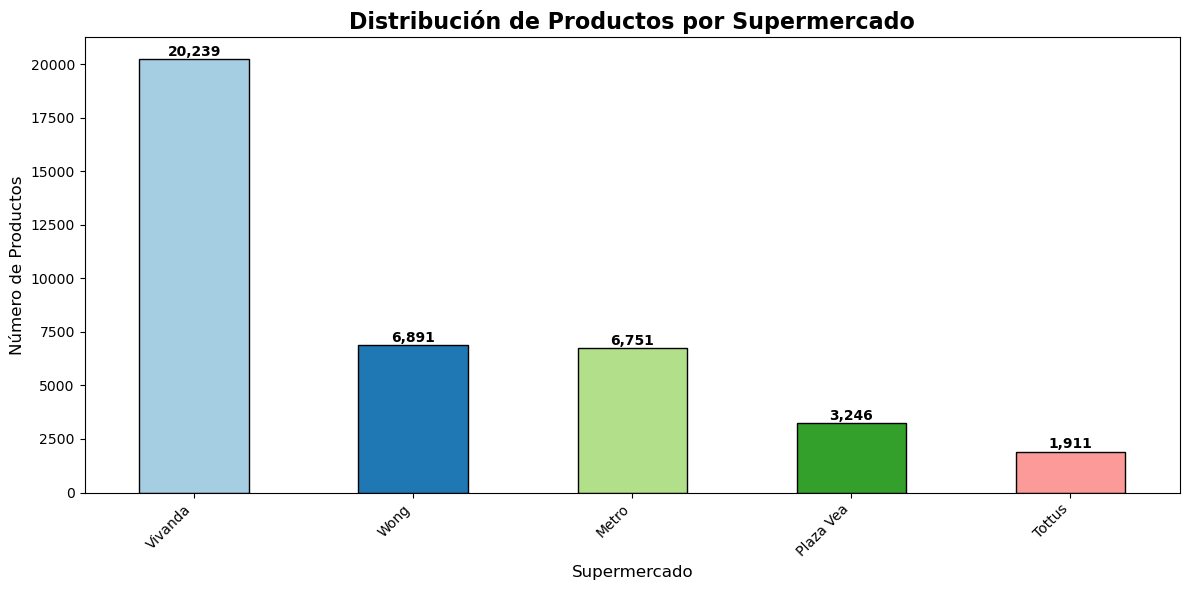

Distribución de productos por supermercado:
- Vivanda: 20,239 productos (51.8%)
- Wong: 6,891 productos (17.7%)
- Metro: 6,751 productos (17.3%)
- Plaza Vea: 3,246 productos (8.3%)
- Tottus: 1,911 productos (4.9%)


In [27]:
# Gráfico de distribución por supermercado
plt.figure(figsize=(12, 6))

# Contar productos por supermercado
super_counts = data['supermercado'].value_counts()

# Crear gráfico con colores personalizados
ax = super_counts.plot(kind='bar', color=plt.cm.Paired(range(len(super_counts))), edgecolor='black')
plt.title('Distribución de Productos por Supermercado', fontsize=16, fontweight='bold')
plt.xlabel('Supermercado', fontsize=12)
plt.ylabel('Número de Productos', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir valores en las barras
for i, v in enumerate(super_counts.values):
    ax.text(i, v + 5, f"{v:,}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas
print("Distribución de productos por supermercado:")
for super, count in super_counts.items():
    percentage = count / len(data) * 100
    print(f"- {super}: {count:,} productos ({percentage:.1f}%)")

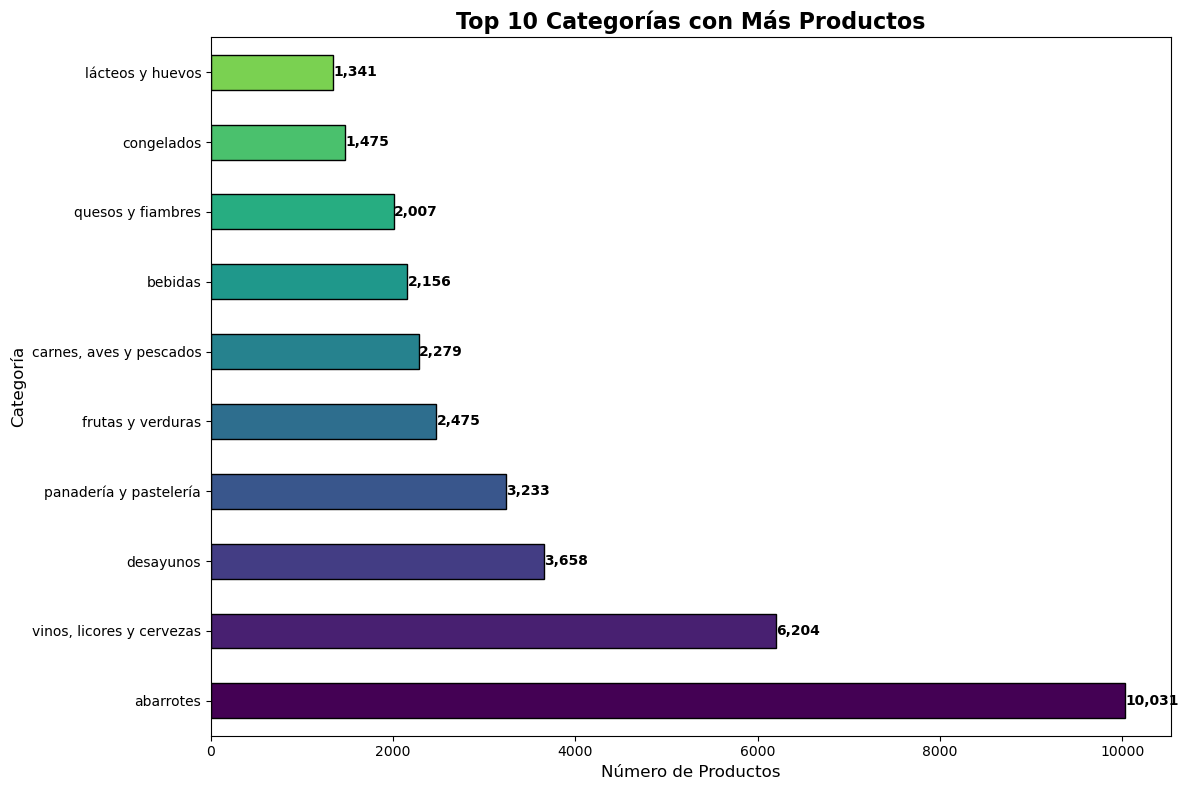

Top 10 categorías (porcentaje del total):
- abarrotes: 10,031 productos (25.7%)
- vinos, licores y cervezas: 6,204 productos (15.9%)
- desayunos: 3,658 productos (9.4%)
- panadería y pastelería: 3,233 productos (8.3%)
- frutas y verduras: 2,475 productos (6.3%)
- carnes, aves y pescados: 2,279 productos (5.8%)
- bebidas: 2,156 productos (5.5%)
- quesos y fiambres: 2,007 productos (5.1%)
- congelados: 1,475 productos (3.8%)
- lácteos y huevos: 1,341 productos (3.4%)


In [28]:
# Top 10 categorías en gráfico horizontal
plt.figure(figsize=(12, 8))

top_categorias = data['categoria'].value_counts().head(10)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_categorias)))

ax = top_categorias.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Top 10 Categorías con Más Productos', fontsize=16, fontweight='bold')
plt.xlabel('Número de Productos', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Añadir valores en las barras
for i, v in enumerate(top_categorias.values):
    ax.text(v + 1, i, f"{v:,}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar porcentaje
print("Top 10 categorías (porcentaje del total):")
for cat, count in top_categorias.items():
    percentage = count / len(data) * 100
    print(f"- {cat}: {count:,} productos ({percentage:.1f}%)")

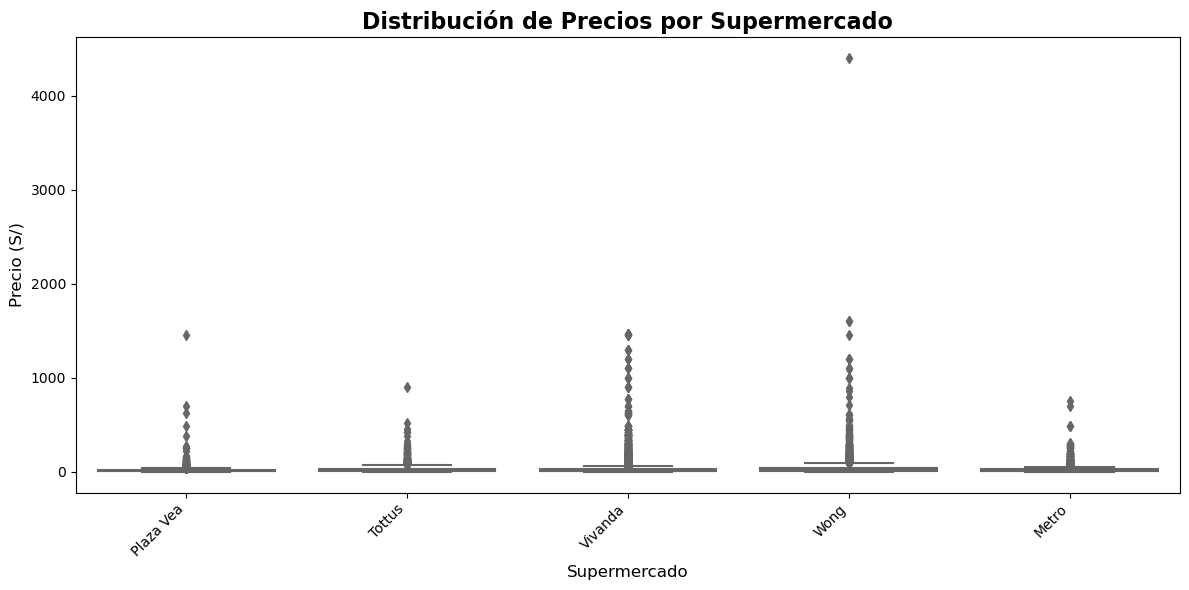

Estadísticas de precio por supermercado:


,Promedio,Mediana,Mínimo,Máximo,Productos
supermercado,,,,,
Wong,38.510003,19.5,0.9,4399.00,6891
Tottus,29.951638,14.9,0.9,899.90,1911
Vivanda,28.338585,13.5,0.0,1468.59,20239
Metro,22.921797,13.5,0.9,749.90,6751
Plaza Vea,16.219350,9.8,0.5,1449.90,3246


c:\Users\Paolo\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


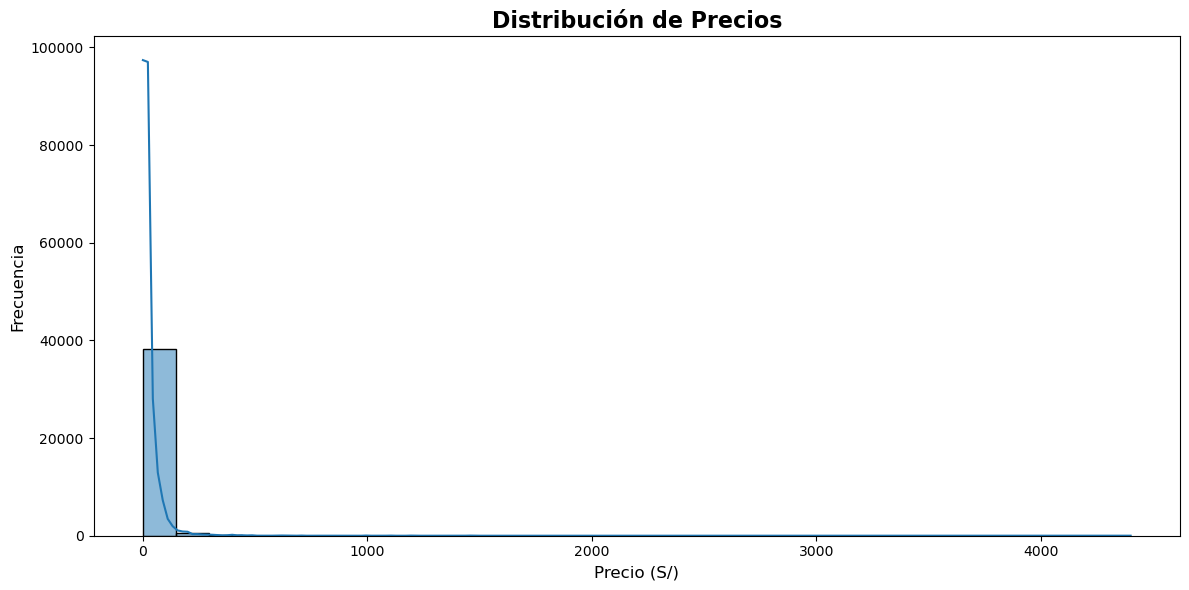

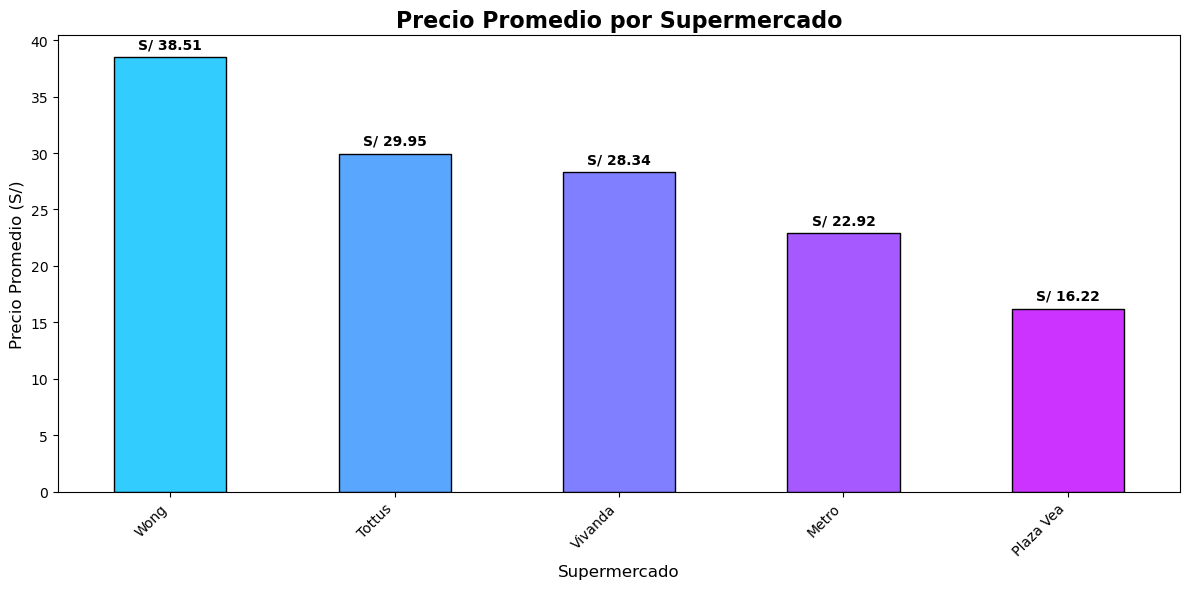

In [29]:
# Análisis de precios
plt.figure(figsize=(12, 6))

# Boxplot de precios por supermercado
sns.boxplot(x='supermercado', y='precio', data=data, palette='Set3')
plt.title('Distribución de Precios por Supermercado', fontsize=16, fontweight='bold')
plt.xlabel('Supermercado', fontsize=12)
plt.ylabel('Precio (S/)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Estadísticas de precios
price_stats = data.groupby('supermercado')['precio'].agg(['mean', 'median', 'min', 'max', 'count'])
price_stats = price_stats.sort_values('mean', ascending=False)
price_stats = price_stats.rename(columns={
    'mean': 'Promedio', 
    'median': 'Mediana', 
    'min': 'Mínimo', 
    'max': 'Máximo',
    'count': 'Productos'
})

print("Estadísticas de precio por supermercado:")
display(price_stats)

# Histograma de precios
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='precio', bins=30, kde=True)
plt.title('Distribución de Precios', fontsize=16, fontweight='bold')
plt.xlabel('Precio (S/)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.show()

# Precios promedio por supermercado (gráfico de barras)
plt.figure(figsize=(12, 6))
avg_price = data.groupby('supermercado')['precio'].mean().sort_values(ascending=False)
ax = avg_price.plot(kind='bar', color=plt.cm.cool(np.linspace(0.2, 0.8, len(avg_price))), edgecolor='black')
plt.title('Precio Promedio por Supermercado', fontsize=16, fontweight='bold')
plt.xlabel('Supermercado', fontsize=12)
plt.ylabel('Precio Promedio (S/)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir valores en las barras
for i, v in enumerate(avg_price.values):
    ax.text(i, v + 0.5, f"S/ {v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
# Eliminar outliers basados en el rango intercuartílico (IQR)
Q1 = data['precio'].quantile(0.25)
Q3 = data['precio'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para outliers (típicamente 1.5*IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Mostrar información sobre los límites
print(f"Estadísticas de distribución de precios:")
print(f"Q1 (25%): S/ {Q1:.2f}")
print(f"Q3 (75%): S/ {Q3:.2f}")
print(f"IQR: S/ {IQR:.2f}")
print(f"Límite inferior para outliers: S/ {max(0, limite_inferior):.2f}")
print(f"Límite superior para outliers: S/ {limite_superior:.2f}")

# Filtrar los outliers
data_sin_outliers = data[(data['precio'] >= max(0, limite_inferior)) & 
                          (data['precio'] <= limite_superior)]

# Ver resultados
print(f"\nPrecios después de eliminar outliers:")
print(f"Mínimo: S/ {data_sin_outliers['precio'].min():.2f}")
print(f"Máximo: S/ {data_sin_outliers['precio'].max():.2f}")
print(f"Promedio: S/ {data_sin_outliers['precio'].mean():.2f}")
print(f"Total de productos: {len(data_sin_outliers)}")
print(f"Outliers eliminados: {len(data) - len(data_sin_outliers)} ({(len(data) - len(data_sin_outliers))/len(data)*100:.1f}%)")

Estadísticas de distribución de precios:
Q1 (25%): S/ 7.00
Q3 (75%): S/ 29.90
IQR: S/ 22.90
Límite inferior para outliers: S/ 0.00
Límite superior para outliers: S/ 64.25

Precios después de eliminar outliers:
Mínimo: S/ 0.00
Máximo: S/ 64.00
Promedio: S/ 17.13
Total de productos: 35347
Outliers eliminados: 3691 (9.5%)


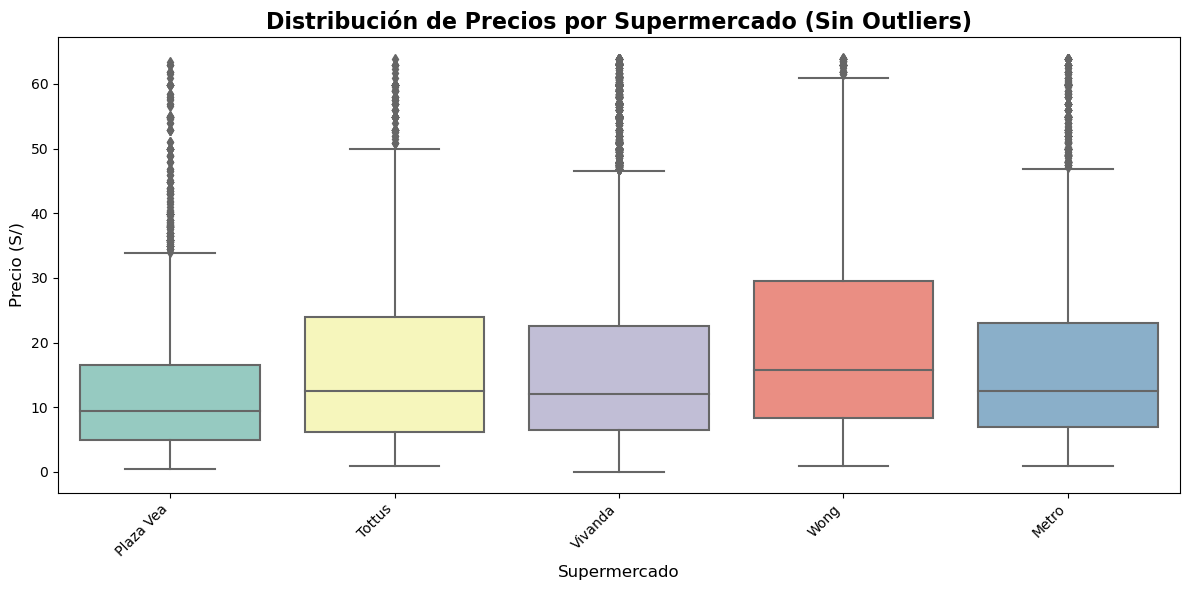

Estadísticas de precio por supermercado (sin outliers):


,Promedio,Mediana,Mínimo,Máximo,Productos
supermercado,,,,,
Wong,20.568746,15.7,0.9,64.0,5838
Tottus,17.442504,12.5,0.9,63.9,1677
Metro,16.994906,12.5,0.9,63.9,6311
Vivanda,16.813939,12.1,0.0,63.9,18366
Plaza Vea,12.699119,9.4,0.5,63.4,3155


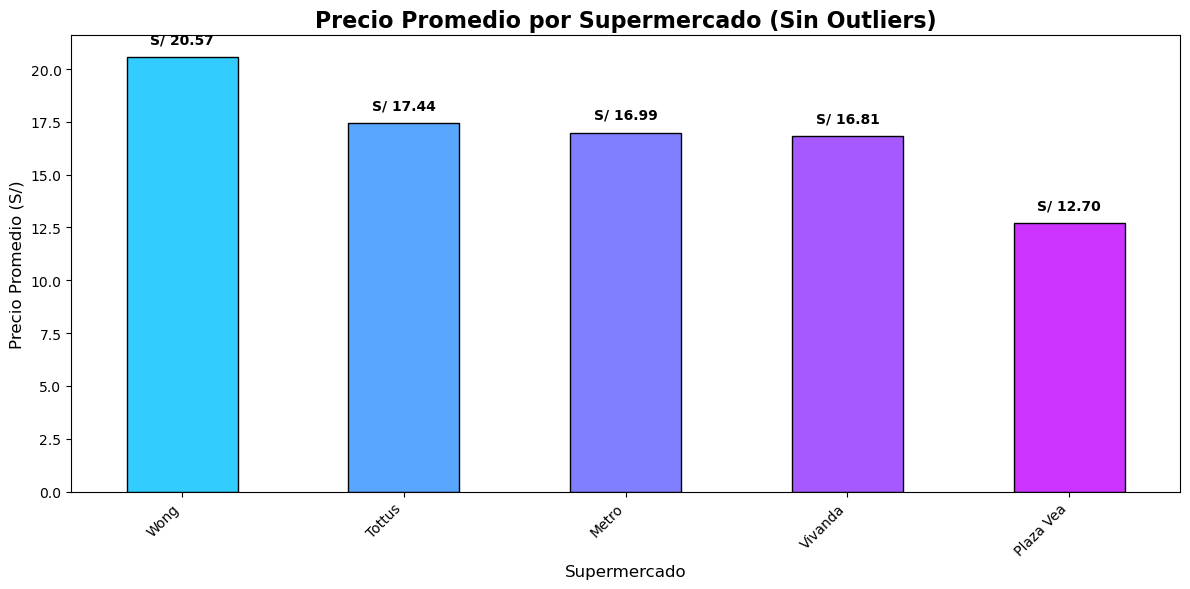

In [31]:
# Elige qué dataset usar para continuar el análisis
# Por ejemplo, usemos el método IQR
data_limpia = data_sin_outliers

# Crear boxplot con datos filtrados
plt.figure(figsize=(12, 6))
sns.boxplot(x='supermercado', y='precio', data=data_limpia, palette='Set3')
plt.title('Distribución de Precios por Supermercado (Sin Outliers)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Supermercado', fontsize=12)
plt.ylabel('Precio (S/)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Estadísticas de precio por supermercado con datos filtrados
price_stats_limpia = data_limpia.groupby('supermercado')['precio'].agg(['mean', 'median', 'min', 'max', 'count'])
price_stats_limpia = price_stats_limpia.sort_values('mean', ascending=False)
price_stats_limpia = price_stats_limpia.rename(columns={
    'mean': 'Promedio', 
    'median': 'Mediana', 
    'min': 'Mínimo', 
    'max': 'Máximo',
    'count': 'Productos'
})

print("Estadísticas de precio por supermercado (sin outliers):")
display(price_stats_limpia)

# Gráfico de barras para precios promedio
plt.figure(figsize=(12, 6))
avg_price_limpia = data_limpia.groupby('supermercado')['precio'].mean().sort_values(ascending=False)
ax = avg_price_limpia.plot(kind='bar', color=plt.cm.cool(np.linspace(0.2, 0.8, len(avg_price_limpia))), 
                          edgecolor='black')
plt.title('Precio Promedio por Supermercado (Sin Outliers)', fontsize=16, fontweight='bold')
plt.xlabel('Supermercado', fontsize=12)
plt.ylabel('Precio Promedio (S/)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir valores en las barras
for i, v in enumerate(avg_price_limpia.values):
    ax.text(i, v + 0.5, f"S/ {v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

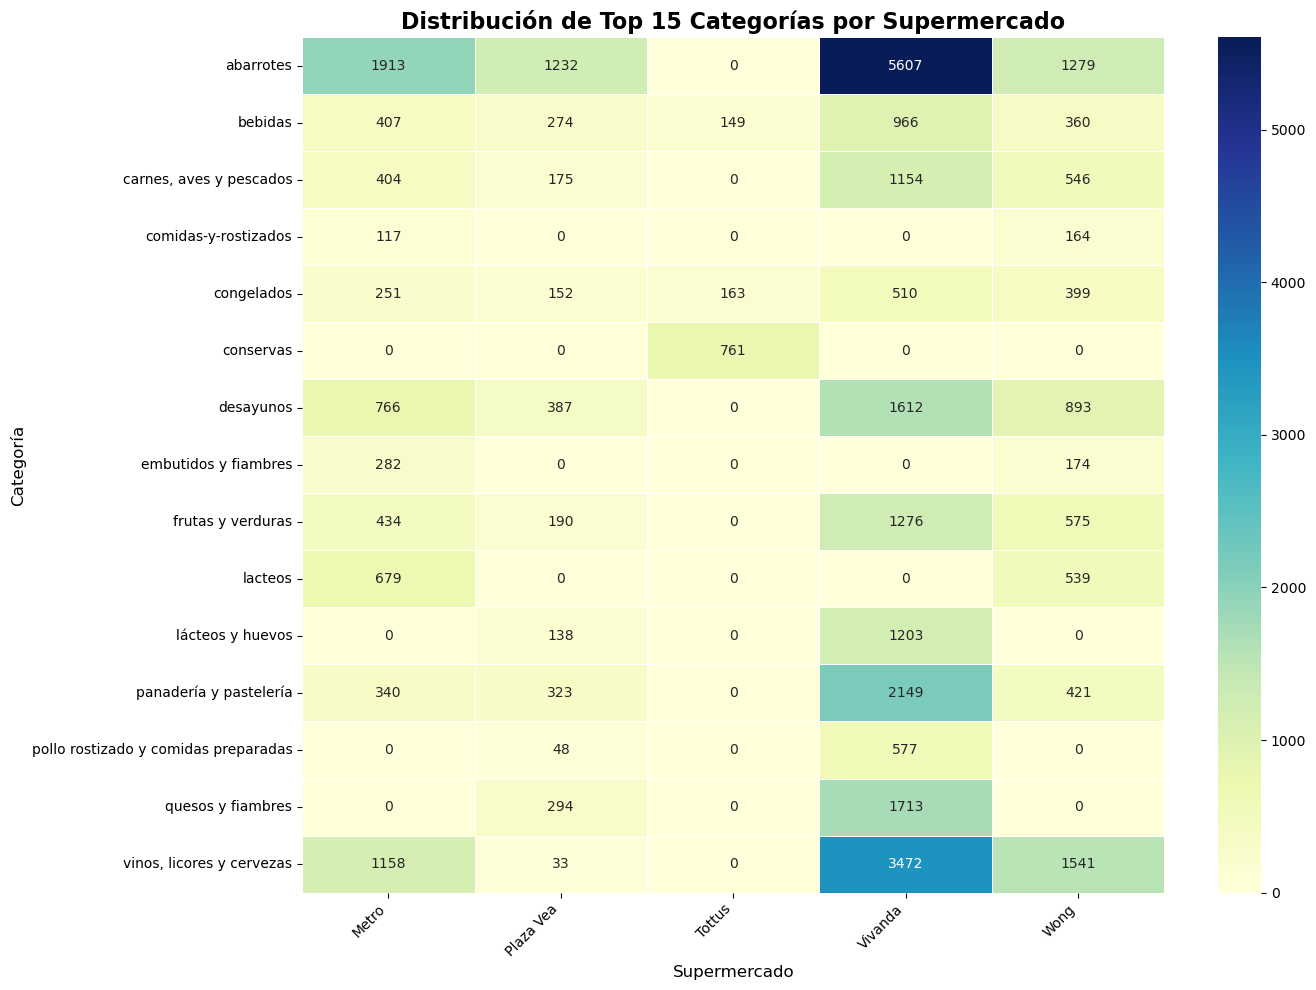

<Figure size 1400x800 with 0 Axes>

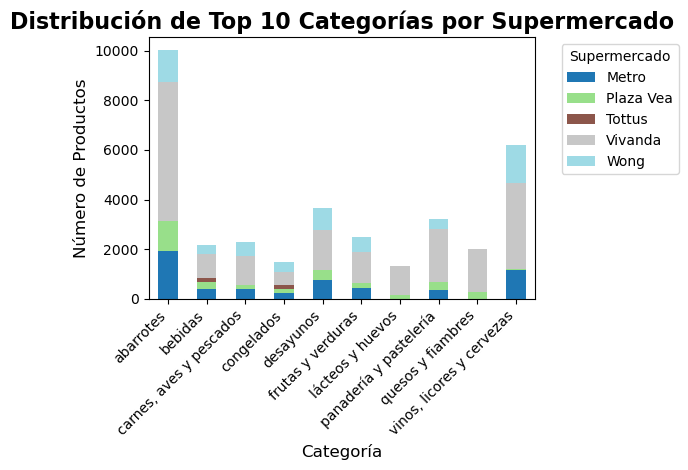

In [32]:
# Heatmap de categorías por supermercado
# Tomar solo las categorías más frecuentes para mejor visualización
top_categories = data['categoria'].value_counts().head(15).index.tolist()
data_filtered = data[data['categoria'].isin(top_categories)]

# Crear tabla cruzada
cross_tab = pd.crosstab(data_filtered['categoria'], data_filtered['supermercado'])

# Crear heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Distribución de Top 15 Categorías por Supermercado', fontsize=16, fontweight='bold')
plt.xlabel('Supermercado', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico de barras apiladas para las 10 categorías principales
top_10_cat = data['categoria'].value_counts().head(10).index
data_top10 = data[data['categoria'].isin(top_10_cat)]
cat_super_pivot = pd.crosstab(data_top10['categoria'], data_top10['supermercado'])

plt.figure(figsize=(14, 8))
cat_super_pivot.plot(kind='bar', stacked=True, colormap='tab20')
plt.title('Distribución de Top 10 Categorías por Supermercado', fontsize=16, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Número de Productos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Supermercado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

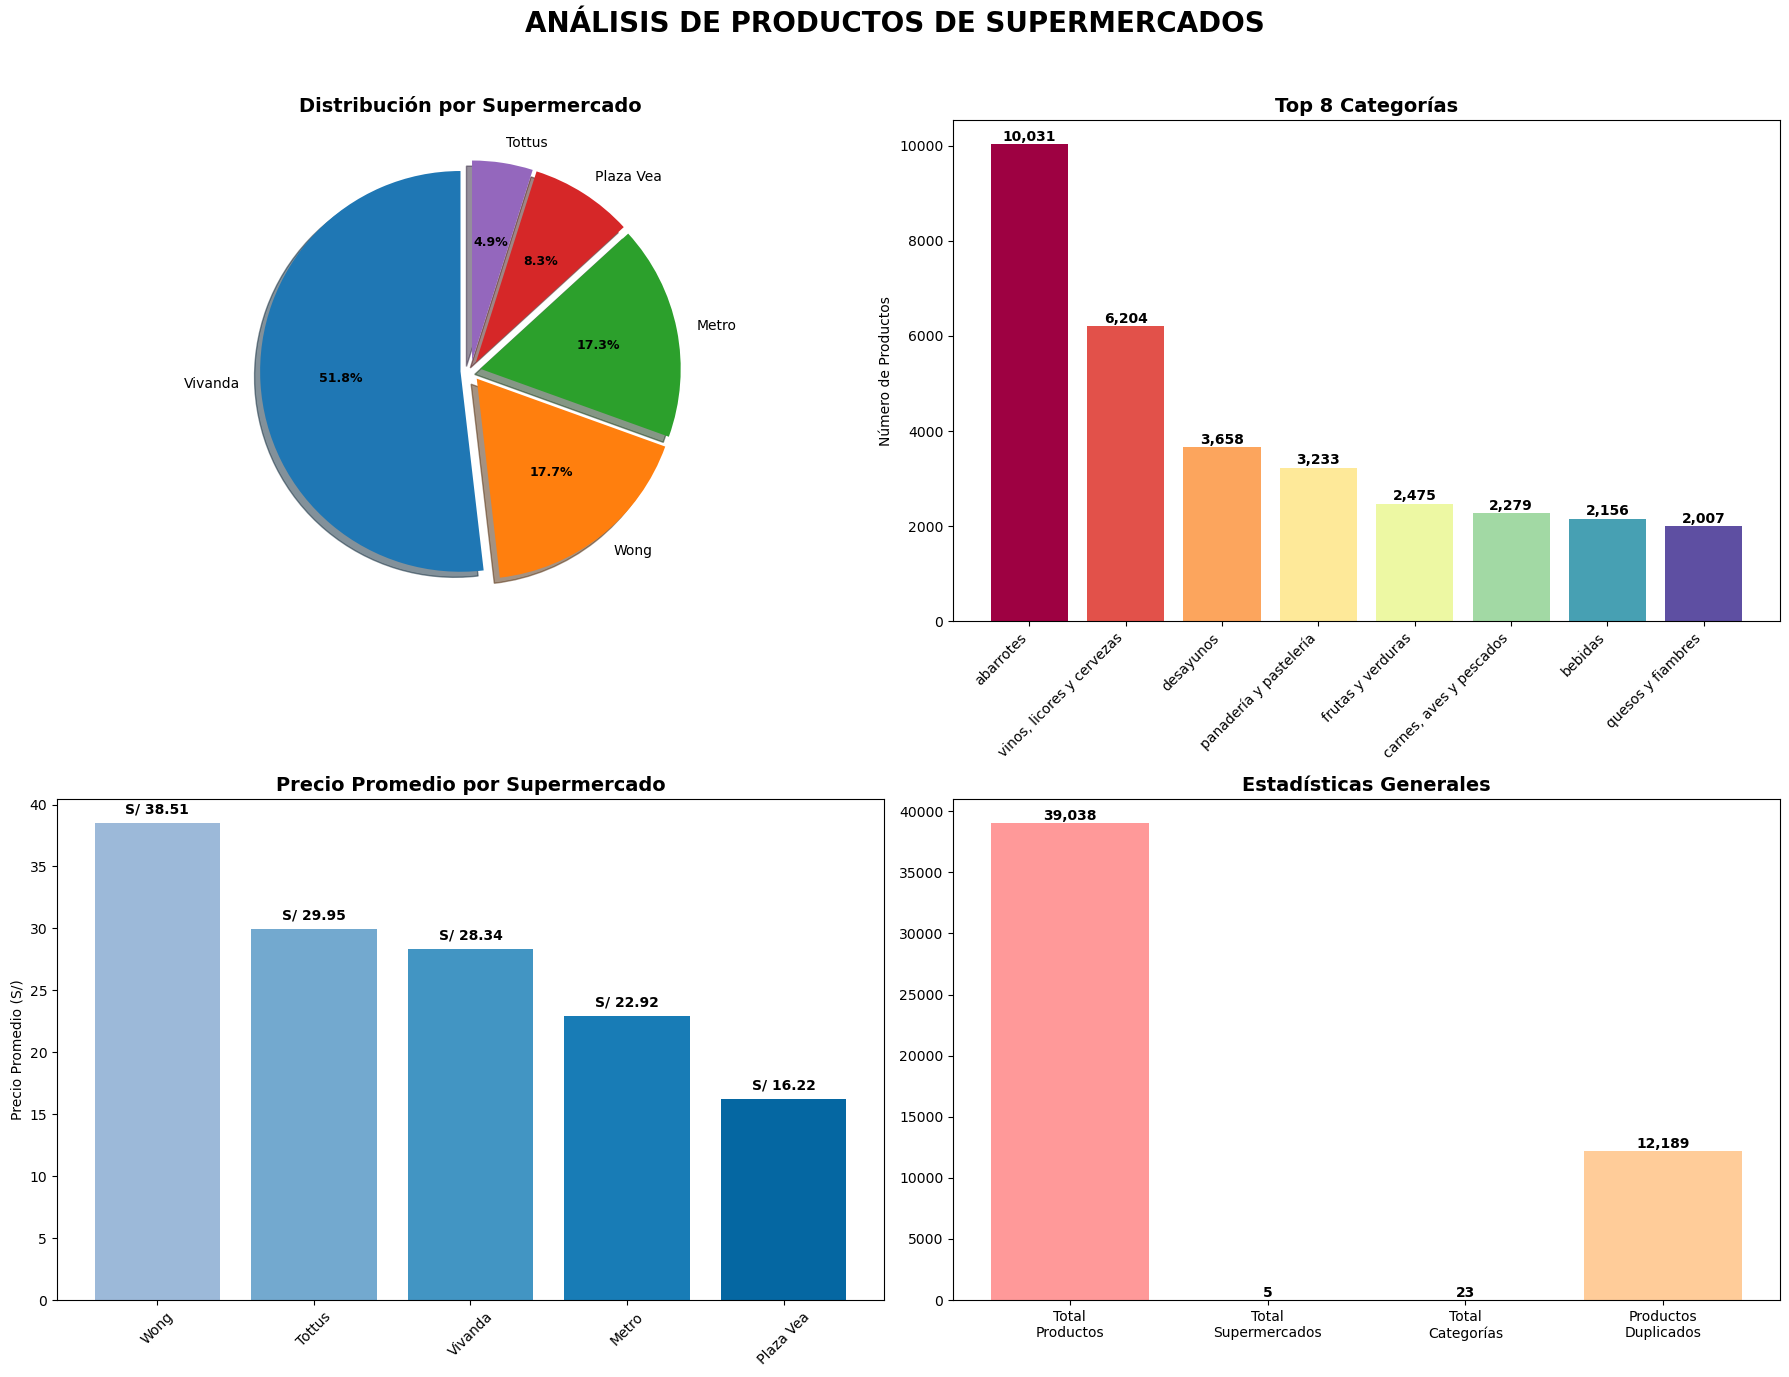

RESUMEN EJECUTIVO DEL ANÁLISIS
• Total de productos: 39,038
• Total de supermercados: 5
• Total de categorías: 23
• Precio promedio general: S/ 28.27
• Precio mínimo: S/ 0.00
• Precio máximo: S/ 4399.00
• Supermercado con más productos: Vivanda (20,239 productos)
• Categoría más común: abarrotes (10,031 productos)
• Supermercado más económico: Plaza Vea (Promedio: S/ 16.22)
• Supermercado más costoso: Wong (Promedio: S/ 38.51)


In [33]:
import numpy as np

# Dashboard completo
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('ANÁLISIS DE PRODUCTOS DE SUPERMERCADOS', fontsize=20, fontweight='bold', y=0.98)

# 1. Distribución por supermercado (pie chart)
super_counts = data['supermercado'].value_counts()
wedges, texts, autotexts = axes[0, 0].pie(
    super_counts.values, 
    labels=super_counts.index, 
    autopct='%1.1f%%',
    colors=plt.cm.tab10(range(len(super_counts))), 
    startangle=90,
    explode=[0.05] * len(super_counts),
    shadow=True
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[0, 0].set_title('Distribución por Supermercado', fontsize=14, fontweight='bold')

# 2. Top 8 categorías
cat_counts = data['categoria'].value_counts().head(8)
bars = axes[0, 1].bar(
    range(len(cat_counts)), 
    cat_counts.values,
    color=plt.cm.Spectral(np.linspace(0, 1, len(cat_counts)))
)
axes[0, 1].set_title('Top 8 Categorías', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(range(len(cat_counts)))
axes[0, 1].set_xticklabels(cat_counts.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Número de Productos', fontsize=10)

# Añadir valores
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2., height + 5,
        f'{int(height):,}', ha='center', va='bottom', fontweight='bold'
    )

# 3. Precios por supermercado
price_by_super = data.groupby('supermercado')['precio'].mean().sort_values(ascending=False)
bars = axes[1, 0].bar(
    price_by_super.index,
    price_by_super.values,
    color=plt.cm.PuBu(np.linspace(0.4, 0.8, len(price_by_super)))
)
axes[1, 0].set_title('Precio Promedio por Supermercado', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('', fontsize=10)
axes[1, 0].set_ylabel('Precio Promedio (S/)', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=45)

# Añadir valores
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(
        bar.get_x() + bar.get_width()/2., height + 0.5,
        f'S/ {height:.2f}', ha='center', va='bottom', fontweight='bold'
    )

# 4. Estadísticas generales
stats = [
    len(data),
    data['supermercado'].nunique(),
    data['categoria'].nunique(),
    data.duplicated().sum()
]
labels = ['Total\nProductos', 'Total\nSupermercados', 'Total\nCategorías', 'Productos\nDuplicados']
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

bars = axes[1, 1].bar(labels, stats, color=colors)
axes[1, 1].set_title('Estadísticas Generales', fontsize=14, fontweight='bold')
for bar, stat in zip(bars, stats):
    height = bar.get_height()
    axes[1, 1].text(
        bar.get_x() + bar.get_width()/2., height + 1,
        f'{stat:,}', ha='center', va='bottom', fontweight='bold'
    )

# Ajustar diseño
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Resumen estadístico
print("=" * 50)
print("RESUMEN EJECUTIVO DEL ANÁLISIS")
print("=" * 50)
print(f"• Total de productos: {len(data):,}")
print(f"• Total de supermercados: {data['supermercado'].nunique()}")
print(f"• Total de categorías: {data['categoria'].nunique()}")
print(f"• Precio promedio general: S/ {data['precio'].mean():.2f}")
print(f"• Precio mínimo: S/ {data['precio'].min():.2f}")
print(f"• Precio máximo: S/ {data['precio'].max():.2f}")
print(f"• Supermercado con más productos: {data['supermercado'].value_counts().index[0]} ({data['supermercado'].value_counts().iloc[0]:,} productos)")
print(f"• Categoría más común: {data['categoria'].value_counts().index[0]} ({data['categoria'].value_counts().iloc[0]:,} productos)")
print(f"• Supermercado más económico: {price_by_super.index[-1]} (Promedio: S/ {price_by_super.iloc[-1]:.2f})")
print(f"• Supermercado más costoso: {price_by_super.index[0]} (Promedio: S/ {price_by_super.iloc[0]:.2f})")
print("=" * 50)